<a href="https://colab.research.google.com/github/kamxsato/MIS444_Final_Project/blob/main/24104087_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Libraries

In [1]:
# 0.1 import libraries
import pandas as pd
import numpy as np
from google.colab import drive
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

drive.mount('/content/drive', force_remount=True)

print(f'Libraries Loaded')

Mounted at /content/drive
Libraries Loaded


# 1. Load Data

In [2]:
# 1.1 load dataset
train = pd.read_csv('/content/drive/MyDrive/死/Summer 2026/MIS444/Project/train.csv')
test = pd.read_csv('/content/drive/MyDrive/死/Summer 2026/MIS444/Project/test.csv')

print(f"✅ Dataset loaded. Shape: {train.shape}")
print('=== train data ===')
display(train.head(3))
display(train.tail(3))

print(f"✅ Dataset loaded. Shape: {test.shape}")
print('=== test data ===')
display(test.head(3))
display(test.tail(3))

✅ Dataset loaded. Shape: (691369, 14)
=== train data ===


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1
691368,691368,21.0,5.64,1.03,3.05,1.01,4.91,169.0,NaN,9.47,Other,Medium,Yes,0


✅ Dataset loaded. Shape: (296302, 13)
=== test data ===


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes
296301,987670,30.0,6.68,2.20,2.13,1.51,NaN,162.0,117.0,7.78,Male,NaN,Yes


In [3]:
# 1.2 inspect data

overview_train = pd.DataFrame({
    'dtype': train.dtypes,
    'nunique': train.nunique(),
    'nulls': train.isnull().sum(),
    'null_%': (train.isnull().mean()*100).round(2),
    'sample': [train[c].dropna().iloc[0] if train[c].notna().any() else 'ALL NULL' for c in train.columns]
})

overview_test = pd.DataFrame({
    'dtype': test.dtypes,
    'nunique': test.nunique(),
    'nulls': test.isnull().sum(),
    'null_%': (test.isnull().mean()*100).round(2),
    'sample': [test[c].dropna().iloc[0] if test[c].notna().any() else 'ALL NULL' for c in test.columns]
})

print(f'=== train data overview ===')
display(overview_train)
print(f'=== test data overview===')
display(overview_test)

=== train data overview ===


,dtype,nunique,nulls,null_%,sample
id,int64,691369,0,0.00,0
age,float64,18,28929,4.18,24.0
daily_screen_time_hours,float64,1389,95854,13.86,5.97
social_media_hours,float64,721,133995,19.38,1.83
gaming_hours,float64,401,126821,18.34,1.59
work_study_hours,float64,600,51518,7.45,2.11
sleep_hours,float64,451,44480,6.43,7.46
notifications_per_day,float64,231,67584,9.78,122.0
app_opens_per_day,float64,166,80710,11.67,38.0
weekend_screen_time,float64,1437,112063,16.21,8.63


=== test data overview===


,dtype,nunique,nulls,null_%,sample
id,int64,296302,0,0.00,691369
age,float64,18,17138,5.78,30.0
daily_screen_time_hours,float64,1349,32788,11.07,9.34
social_media_hours,float64,703,47397,16.00,1.91
gaming_hours,float64,401,59420,20.05,0.77
work_study_hours,float64,601,27777,9.37,4.09
sleep_hours,float64,451,22455,7.58,7.15
notifications_per_day,float64,231,34221,11.55,153.0
app_opens_per_day,float64,166,25705,8.68,16.0
weekend_screen_time,float64,1404,50697,17.11,10.68


In [4]:
display(train.describe(include='all').T)
display(test.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,691369.0,NaN,NaN,NaN,345684.0,199581.183466,0.0,172842.0,345684.0,518526.0,691368.0
age,662440.0,NaN,NaN,NaN,26.615408,5.153162,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,595515.0,NaN,NaN,NaN,7.640865,2.721446,0.5,5.48,7.77,9.84,15.0
social_media_hours,557374.0,NaN,NaN,NaN,2.471038,1.316137,0.0,1.45,2.31,3.37,8.0
gaming_hours,564548.0,NaN,NaN,NaN,1.459265,0.934552,0.0,0.7,1.33,2.09,4.0
work_study_hours,639851.0,NaN,NaN,NaN,2.366971,1.258797,0.0,1.36,2.2,3.2,6.0
sleep_hours,646889.0,NaN,NaN,NaN,6.804334,1.234512,4.5,5.78,6.8,7.87,9.0
notifications_per_day,623785.0,NaN,NaN,NaN,145.8949,65.917556,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,610659.0,NaN,NaN,NaN,102.636781,48.09397,15.0,64.0,104.0,145.0,180.0
weekend_screen_time,579306.0,NaN,NaN,NaN,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,296302.0,NaN,NaN,NaN,839519.5,85535.164068,691369.0,765444.25,839519.5,913594.75,987670.0
age,279164.0,NaN,NaN,NaN,26.608689,5.153359,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,263514.0,NaN,NaN,NaN,7.640771,2.725921,0.5,5.46,7.77,9.85,15.0
social_media_hours,248905.0,NaN,NaN,NaN,2.471224,1.318143,0.0,1.45,2.32,3.37,7.85
gaming_hours,236882.0,NaN,NaN,NaN,1.457668,0.934727,0.0,0.69,1.33,2.09,4.0
work_study_hours,268525.0,NaN,NaN,NaN,2.365962,1.257023,0.0,1.36,2.2,3.2,6.0
sleep_hours,273847.0,NaN,NaN,NaN,6.801704,1.23608,4.5,5.77,6.8,7.87,9.0
notifications_per_day,262081.0,NaN,NaN,NaN,145.748066,66.014554,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,270597.0,NaN,NaN,NaN,102.656216,48.1862,15.0,63.0,104.0,145.0,180.0
weekend_screen_time,245605.0,NaN,NaN,NaN,9.474575,2.858384,0.51,7.27,9.58,11.75,17.56


# 2. Preprocessing

In [5]:
# 2.1 Missing Values
# 2.1.1 Missing values detection

missing_train = pd.DataFrame({
    'Data Type': train.dtypes,
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_train[missing_train['Missing Count'] > 0]

missing_test = pd.DataFrame({
    'Data Type': test.dtypes,
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_test[missing_test['Missing Count'] > 0]

print(f'=== train data missing value ===')
display(missing_train)
print(f'=== test data missing value ===')
display(missing_test)

=== train data missing value ===


,Data Type,Missing Count,Missing %
social_media_hours,float64,133995,19.38
gaming_hours,float64,126821,18.34
weekend_screen_time,float64,112063,16.21
daily_screen_time_hours,float64,95854,13.86
app_opens_per_day,float64,80710,11.67
notifications_per_day,float64,67584,9.78
stress_level,object,55148,7.98
work_study_hours,float64,51518,7.45
sleep_hours,float64,44480,6.43
academic_work_impact,object,44224,6.40


=== test data missing value ===


,Data Type,Missing Count,Missing %
gaming_hours,float64,59420,20.05
weekend_screen_time,float64,50697,17.11
social_media_hours,float64,47397,16.00
notifications_per_day,float64,34221,11.55
daily_screen_time_hours,float64,32788,11.07
work_study_hours,float64,27777,9.37
app_opens_per_day,float64,25705,8.68
academic_work_impact,object,25721,8.68
sleep_hours,float64,22455,7.58
stress_level,object,19626,6.62


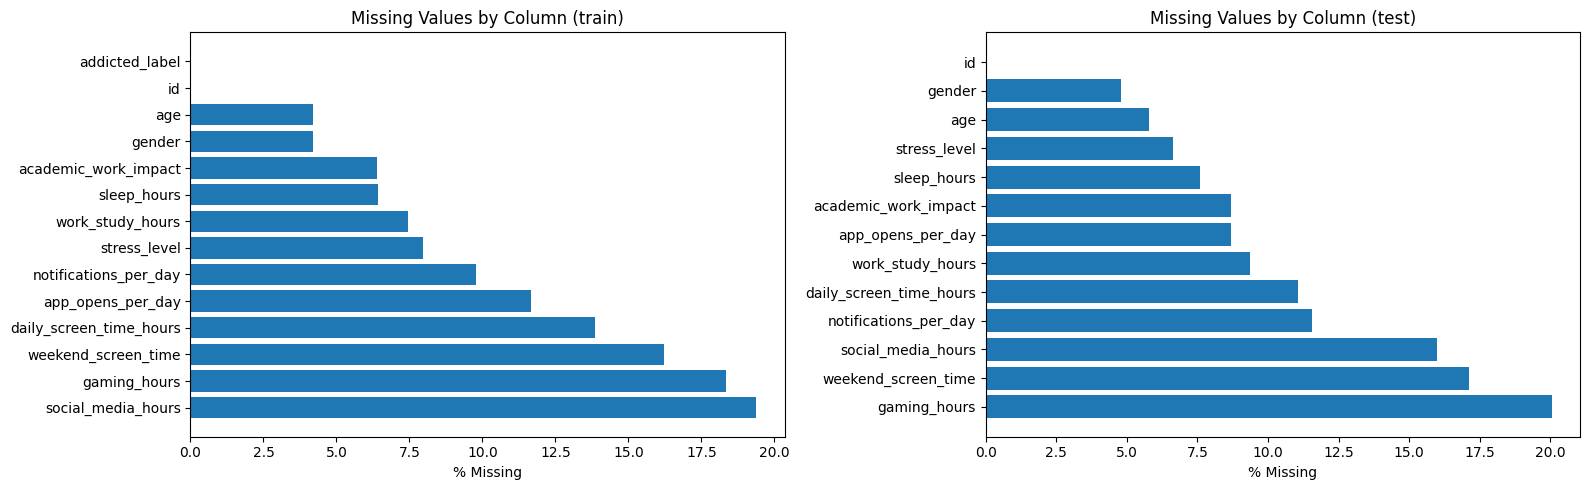

In [6]:
# 2.1.2 missing data visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(missing_train.index, missing_train['Missing %'])
axes[0].set_xlabel('% Missing')
axes[0].set_title('Missing Values by Column (train)')

axes[1].barh(missing_test.index, missing_test['Missing %'])
axes[1].set_xlabel('% Missing')
axes[1].set_title('Missing Values by Column (test)')
plt.tight_layout()
plt.show()

In [7]:
# 2.1.3 missing value treatment
# Median for numeric data with less than 10% missing data
age_median_train = train['age'].median()
age_median_test = test['age'].median()
train['age'] = train['age'].fillna(age_median_train)
test['age'] = test['age'].fillna(age_median_test)

print(f'Age median fill(train): {age_median_train}')
print(f'Age median fill(test): {age_median_test}')

Age median fill(train): 27.0
Age median fill(test): 27.0


In [8]:
sleep_hours_median_train = train['sleep_hours'].median()
sleep_hours_median_test = test['sleep_hours'].median()
train['sleep_hours'] = train['sleep_hours'].fillna(sleep_hours_median_train)
test['sleep_hours'] = test['sleep_hours'].fillna(sleep_hours_median_test)

print(f'sleep_hours median fill(train): {sleep_hours_median_train}')
print(f'sleep_hours median fill(test): {sleep_hours_median_test}')

sleep_hours median fill(train): 6.8
sleep_hours median fill(test): 6.8


In [9]:
work_study_hours_median_train = train['work_study_hours'].median()
work_study_hours_median_test = test['work_study_hours'].median()
train['work_study_hours'] = train['work_study_hours'].fillna(work_study_hours_median_train)
test['work_study_hours'] = test['work_study_hours'].fillna(work_study_hours_median_test)

print(f'work_study_hours median fill(train): {work_study_hours_median_train}')
print(f'work_study_hours median fill(test): {work_study_hours_median_test}')

work_study_hours median fill(train): 2.2
work_study_hours median fill(test): 2.2


In [10]:
notifications_per_day_median_train = train['notifications_per_day'].median()
train['notifications_per_day'] = train['notifications_per_day'].fillna(notifications_per_day_median_train)

print(f'notifications_per_day median fill(train): {notifications_per_day_median_train}')

notifications_per_day median fill(train): 150.0


In [11]:
app_opens_per_day_median_test = test['app_opens_per_day'].median()
test['app_opens_per_day'] = test['app_opens_per_day'].fillna(app_opens_per_day_median_test)

print(f'app_opens_per_day median fill(test): {app_opens_per_day_median_test}')

app_opens_per_day median fill(test): 104.0


In [12]:
# Iterative Imputation for missing value greater than 10%
test['notifications_per_day'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(test[['notifications_per_day']])
train['app_opens_per_day'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(train[['app_opens_per_day']])
train['daily_screen_time_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(train[['daily_screen_time_hours']])
test['daily_screen_time_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(test[['daily_screen_time_hours']])
train['weekend_screen_time'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(train[['weekend_screen_time']])
test['weekend_screen_time'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(test[['weekend_screen_time']])
train['gaming_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(train[['gaming_hours']])
test['gaming_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(test[['gaming_hours']])
train['social_media_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(train[['social_media_hours']])
test['social_media_hours'] = IterativeImputer(max_iter=10, random_state=0).fit_transform(test[['social_media_hours']])

In [13]:
# Mode for categorical data
train['stress_level'] = train['stress_level'].fillna(train['stress_level'].mode()[0])
train['academic_work_impact'] = train['academic_work_impact'].fillna(train['academic_work_impact'].mode()[0])
train['gender'] = train['gender'].fillna(train['gender'].mode()[0])

test['stress_level'] = test['stress_level'].fillna(test['stress_level'].mode()[0])
test['academic_work_impact'] = test['academic_work_impact'].fillna(test['academic_work_impact'].mode()[0])
test['gender'] = test['gender'].fillna(test['gender'].mode()[0])

In [14]:
# 2.1.4 missing values after imputation

missing_train = pd.DataFrame({
    'Data Type': train.dtypes,
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_train[missing_train['Missing Count'] > 0]

missing_test = pd.DataFrame({
    'Data Type': test.dtypes,
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_test[missing_test['Missing Count'] > 0]

print(f'=== train data missing value ===')
display(missing_train)
print(f'=== test data missing value ===')
display(missing_test)

=== train data missing value ===


,Data Type,Missing Count,Missing %
id,int64,0,0.0
age,float64,0,0.0
daily_screen_time_hours,float64,0,0.0
social_media_hours,float64,0,0.0
gaming_hours,float64,0,0.0
work_study_hours,float64,0,0.0
sleep_hours,float64,0,0.0
notifications_per_day,float64,0,0.0
app_opens_per_day,float64,0,0.0
weekend_screen_time,float64,0,0.0


=== test data missing value ===


,Data Type,Missing Count,Missing %
id,int64,0,0.0
age,float64,0,0.0
daily_screen_time_hours,float64,0,0.0
social_media_hours,float64,0,0.0
gaming_hours,float64,0,0.0
work_study_hours,float64,0,0.0
sleep_hours,float64,0,0.0
notifications_per_day,float64,0,0.0
app_opens_per_day,float64,0,0.0
weekend_screen_time,float64,0,0.0


In [15]:
# 2.2 Duplicates
# 2.2.1 Duplicate value detection

n_dupes_train = train.duplicated().sum()
n_dupes_test = test.duplicated().sum()

print(f'Exact duplicate rows in train: {n_dupes_train}')
print(f'Exact duplicate rows in test: {n_dupes_test}')

Exact duplicate rows in train: 0
Exact duplicate rows in test: 0


In [16]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [17]:
# 2.3 Outliers
# 2.3.1 Outlier Detection using IQR

num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('Train IQR Outlier Bounds:')
for col in num_cols:
    lo, hi = iqr_bounds(train[col].dropna())
    n_out  = ((train[col] < lo) | (train[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

print('Test IQR Outlier Bounds:')
for col in num_cols:
    lo, hi = iqr_bounds(test[col].dropna())
    n_out  = ((test[col] < lo) | (test[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

Train IQR Outlier Bounds:
  age             lower=      8.50  upper=     44.50  outliers=0
  daily_screen_time_hours lower=      0.23  upper=     15.16  outliers=0
  social_media_hours lower=     -0.50  upper=      5.26  outliers=12821
  gaming_hours    lower=     -0.77  upper=      3.50  outliers=15125
  work_study_hours lower=     -1.12  upper=      5.64  outliers=6634
  sleep_hours     lower=      2.98  upper=     10.66  outliers=0
  notifications_per_day lower=    -40.50  upper=    339.50  outliers=0
  app_opens_per_day lower=    -38.50  upper=    245.50  outliers=0
  weekend_screen_time lower=      2.29  upper=     16.77  outliers=930
Test IQR Outlier Bounds:
  age             lower=      8.50  upper=     44.50  outliers=0
  daily_screen_time_hours lower=     -0.24  upper=     15.57  outliers=0
  social_media_hours lower=     -0.72  upper=      5.49  outliers=4281
  gaming_hours    lower=     -0.69  upper=      3.42  outliers=7944
  work_study_hours lower=     -1.00  upper=      5

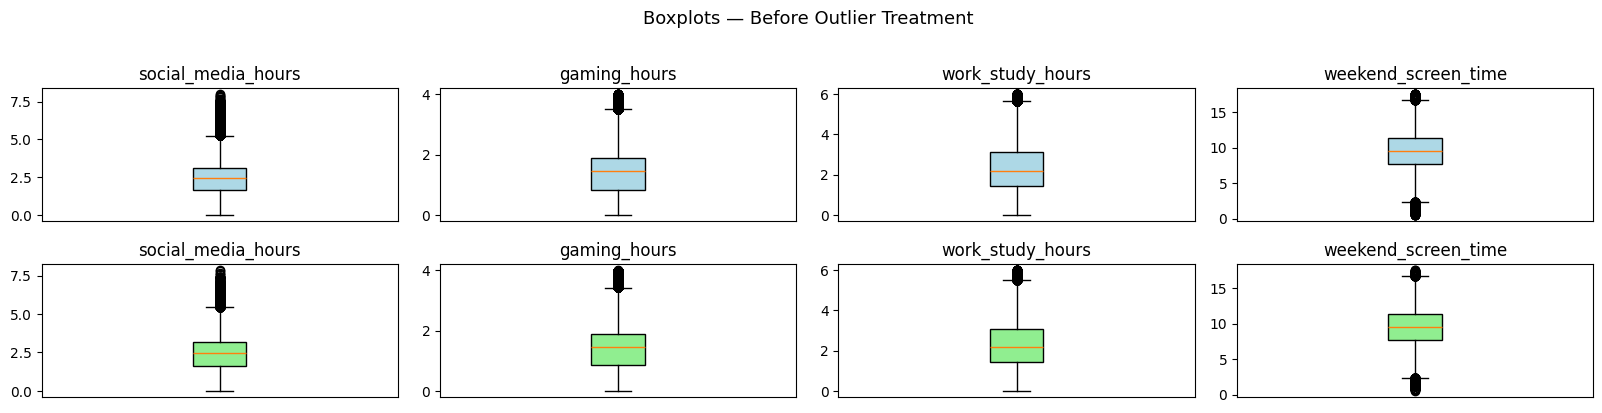

In [18]:
# 2.3.2 Outlier detection using Boxplots
num_cols_outl = ['social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time']

fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, col in zip(axes[0], num_cols_outl):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xticks([])

for ax, col in zip(axes[1], num_cols_outl):
    ax.boxplot(test[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots — Before Outlier Treatment', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Outlier treatment using capping (winsorization)

train['social_media_hours'] = np.asarray(winsorize(train['social_media_hours'], limits=(0.05, 0.05)))
train['gaming_hours'] = np.asarray(winsorize(train['gaming_hours'], limits=(0.05, 0.05)))
train['work_study_hours'] = np.asarray(winsorize(train['work_study_hours'], limits=(0.05, 0.05)))
train['weekend_screen_time'] = np.asarray(winsorize(train['weekend_screen_time'], limits=(0.05, 0.05)))

test['social_media_hours'] = np.asarray(winsorize(test['social_media_hours'], limits=(0.05, 0.05)))
test['gaming_hours'] = np.asarray(winsorize(test['gaming_hours'], limits=(0.05, 0.05)))
test['work_study_hours'] = np.asarray(winsorize(test['work_study_hours'], limits=(0.05, 0.05)))
test['weekend_screen_time'] = np.asarray(winsorize(test['weekend_screen_time'], limits=(0.05, 0.05)))

In [20]:
# IQR after outlier treatment

num_cols_outl = ['social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time']

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('Train IQR Outlier Bounds:')
for col in num_cols_outl:
    lo, hi = iqr_bounds(train[col].dropna())
    n_out  = ((train[col] < lo) | (train[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

print('Test IQR Outlier Bounds:')
for col in num_cols_outl:
    lo, hi = iqr_bounds(test[col].dropna())
    n_out  = ((test[col] < lo) | (test[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

Train IQR Outlier Bounds:
  social_media_hours lower=     -0.50  upper=      5.26  outliers=0
  gaming_hours    lower=     -0.77  upper=      3.50  outliers=0
  work_study_hours lower=     -1.12  upper=      5.64  outliers=0
  weekend_screen_time lower=      2.29  upper=     16.77  outliers=0
Test IQR Outlier Bounds:
  social_media_hours lower=     -0.72  upper=      5.49  outliers=0
  gaming_hours    lower=     -0.69  upper=      3.42  outliers=0
  work_study_hours lower=     -1.00  upper=      5.51  outliers=0
  weekend_screen_time lower=      2.36  upper=     16.68  outliers=0


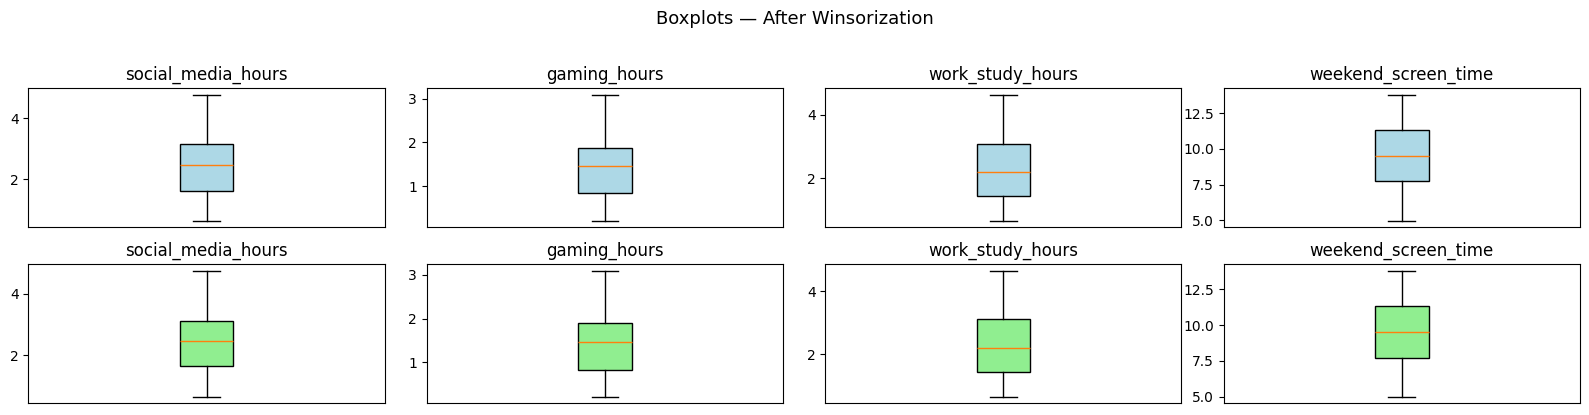

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, col in zip(axes[0], num_cols_outl):
    ax.boxplot(test[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xticks([])

for ax, col in zip(axes[1], num_cols_outl):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots — After Winsorization', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# 2.4 Normalization


# 2.5 Scaling

In [23]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [24]:
# 2.6 Encode Categorial data
# 2.6.1 Encode gender using One-hot encoding

train = pd.get_dummies(
    train,
    columns = ['gender'],
    dtype=int
)
test = pd.get_dummies(
    test,
    columns = ['gender'],
    dtype=int
)

In [25]:
# 2.6.2 Encode stress_level using ordinal encoding

train['stress_level_encoded'] = OrdinalEncoder(categories=[['Low', 'Medium', 'High']]).fit_transform(train[['stress_level']])
test['stress_level_encoded'] = OrdinalEncoder(categories=[['Low', 'Medium', 'High']]).fit_transform(test[['stress_level']])

In [26]:
# 2.6.3 Encode academic_work_impact using label encoder

train['academic_work_impact_n'] = LabelEncoder().fit_transform(train['academic_work_impact'])
test['academic_work_impact_n'] = LabelEncoder().fit_transform(test['academic_work_impact'])

# 3. EDA

In [27]:
# 3.1 Univariate Analysis
# 3.1.1 Numeric summary statistics + skewness & kurtosis

num_cols_train = train.select_dtypes(include='number').columns.tolist()
stats_train = train[num_cols_train].agg(['mean','median','std','skew']).T
stats_train['kurtosis'] = train[num_cols_train].kurtosis()
stats_train['cv_%'] = (train[num_cols_train].std() / train[num_cols_train].mean() * 100).round(2)

num_cols_test = test.select_dtypes(include='number').columns.tolist()
stats_test = test[num_cols_test].agg(['mean','median','std','skew']).T
stats_test['kurtosis'] = test[num_cols_test].kurtosis()
stats_test['cv_%'] = (test[num_cols_test].std() / test[num_cols_test].mean() * 100).round(2)

print(f'Train data EDA')
display(stats_train.round(3))
print(f'Test data EDA')
display(stats_test.round(3))

Train data EDA


,mean,median,std,skew,kurtosis,cv_%
id,345684.000,345684.000,199581.183,0.000,-1.200,57.74
age,26.632,27.000,5.045,-0.047,-1.140,18.94
daily_screen_time_hours,7.641,7.641,2.526,-0.142,-0.587,33.06
social_media_hours,2.457,2.471,1.098,0.346,-0.462,44.71
gaming_hours,1.444,1.459,0.791,0.395,-0.509,54.76
work_study_hours,2.335,2.200,1.135,0.430,-0.703,48.61
sleep_hours,6.804,6.800,1.194,-0.006,-1.000,17.55
notifications_per_day,146.296,150.000,62.625,-0.237,-0.923,42.81
app_opens_per_day,102.637,102.637,45.200,-0.135,-0.924,44.04
weekend_screen_time,9.480,9.480,2.451,-0.073,-0.766,25.86


Test data EDA


,mean,median,std,skew,kurtosis,cv_%
id,839519.500,839519.500,85535.164,-0.000,-1.200,10.19
age,26.631,27.000,5.003,-0.048,-1.109,18.79
daily_screen_time_hours,7.641,7.641,2.571,-0.139,-0.668,33.64
social_media_hours,2.457,2.471,1.127,0.351,-0.547,45.85
gaming_hours,1.443,1.458,0.782,0.394,-0.467,54.21
work_study_hours,2.330,2.200,1.120,0.436,-0.662,48.08
sleep_hours,6.802,6.800,1.188,-0.007,-0.979,17.47
notifications_per_day,145.748,145.748,62.085,-0.216,-0.895,42.60
app_opens_per_day,102.773,104.000,46.050,-0.139,-0.998,44.81
weekend_screen_time,9.475,9.475,2.439,-0.076,-0.746,25.74


In [ ]:
# 3.1.2 Histogram + KDE



In [ ]:
# 3.2 Bivariate Analysis

